<a href="https://colab.research.google.com/github/Fahreiza/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
# Accessing My Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Pastikan Anda memiliki folder 'images' di drive Anda dengan gambar-gambar yang diperlukan.
# Contoh path: '/content/drive/MyDrive/images/'
# Anda mungkin perlu menyesuaikan path ini sesuai dengan struktur folder Anda.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== WEEK 6 PRACTICUM ===
Module 6: Histogram, Histogram Equalization, Dithering

TASK 3: Creating Image Histogram (Manual Implementation)


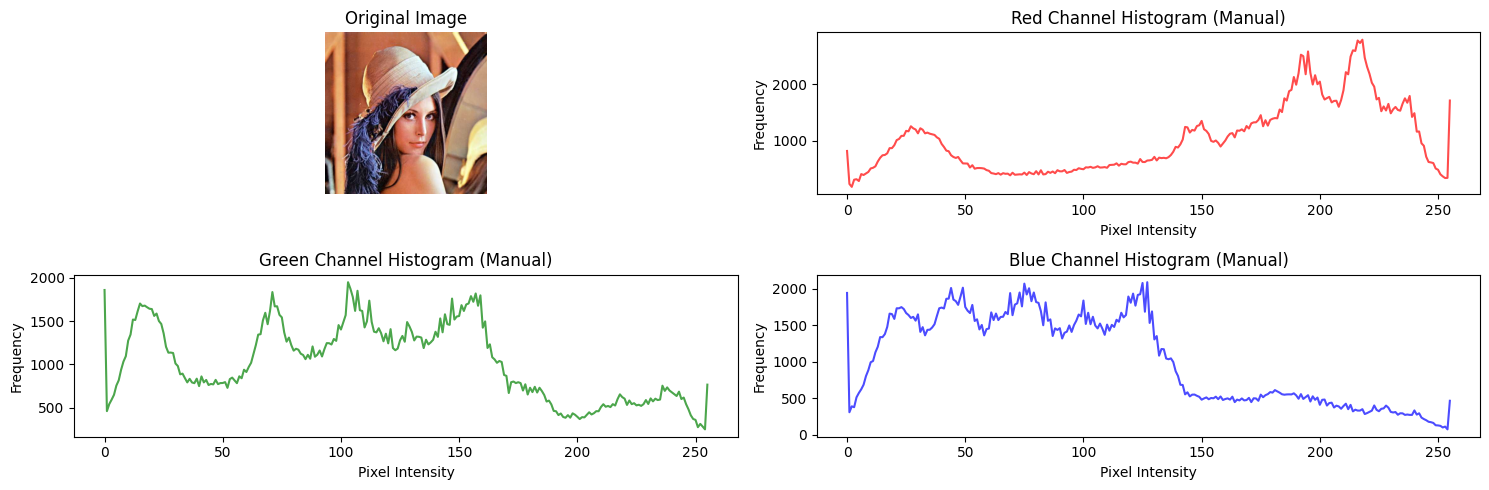

✓ Manual histogram created successfully

TASK 4: Comparing Manual Histogram with NumPy


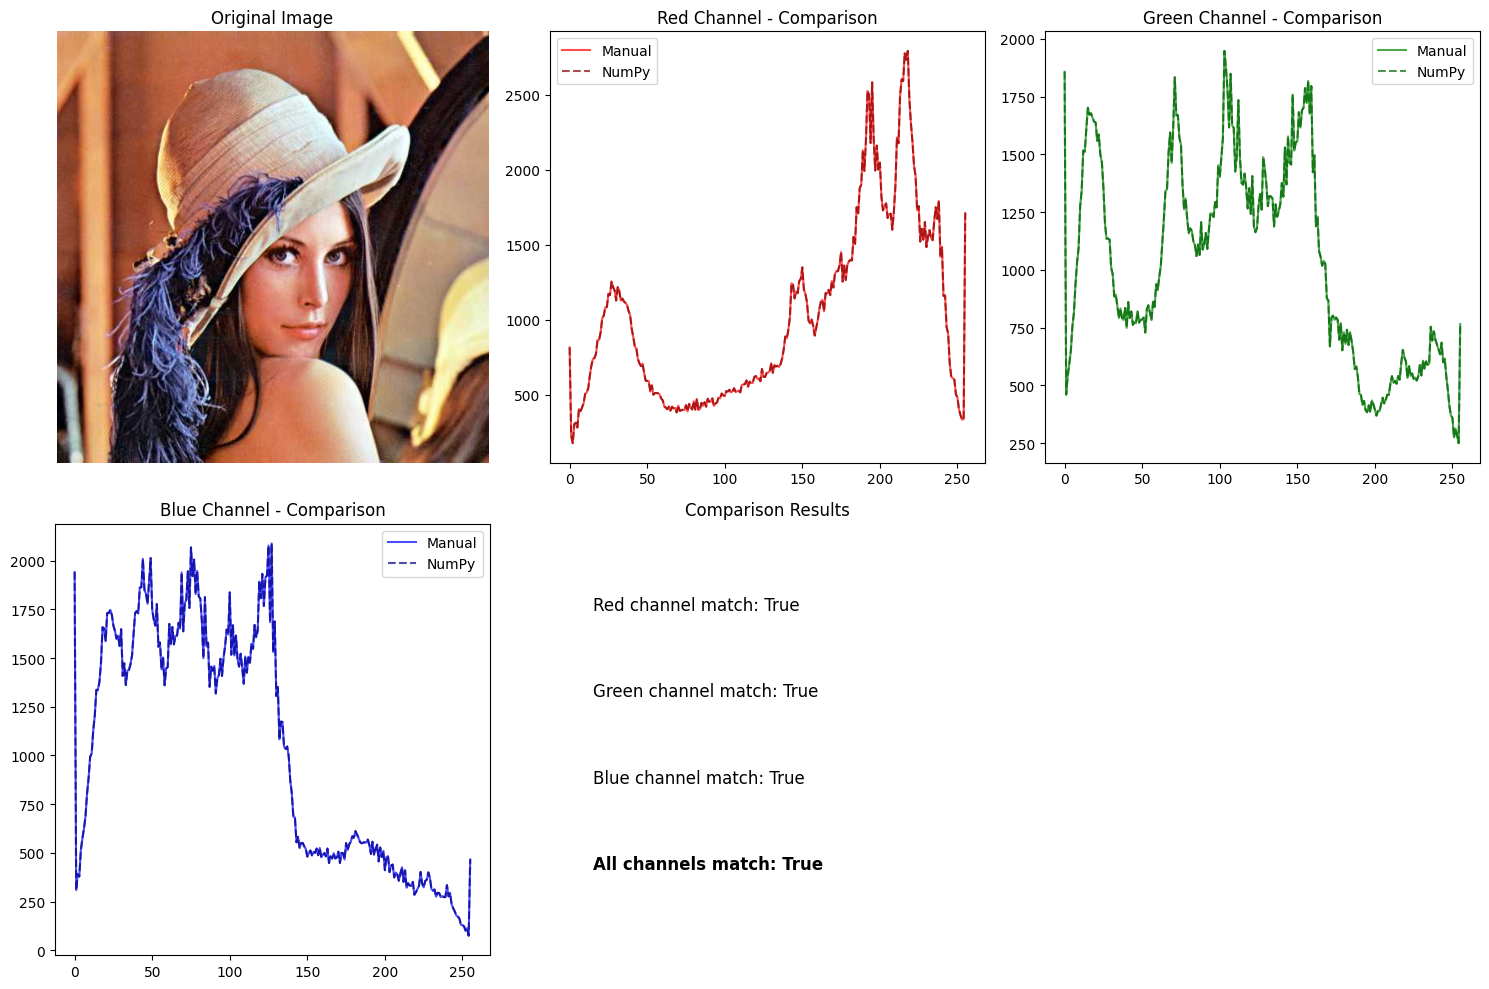

✓ Histogram comparison completed. Results match: True

TASK 5: Manual Histogram Equalization


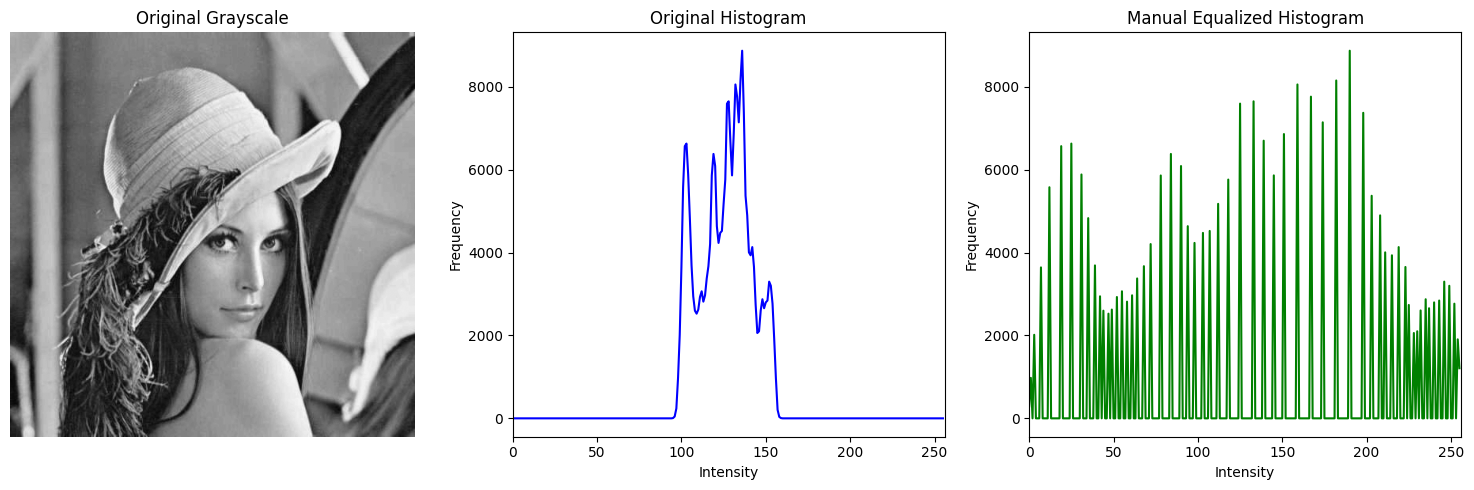

✓ Manual histogram equalization completed successfully


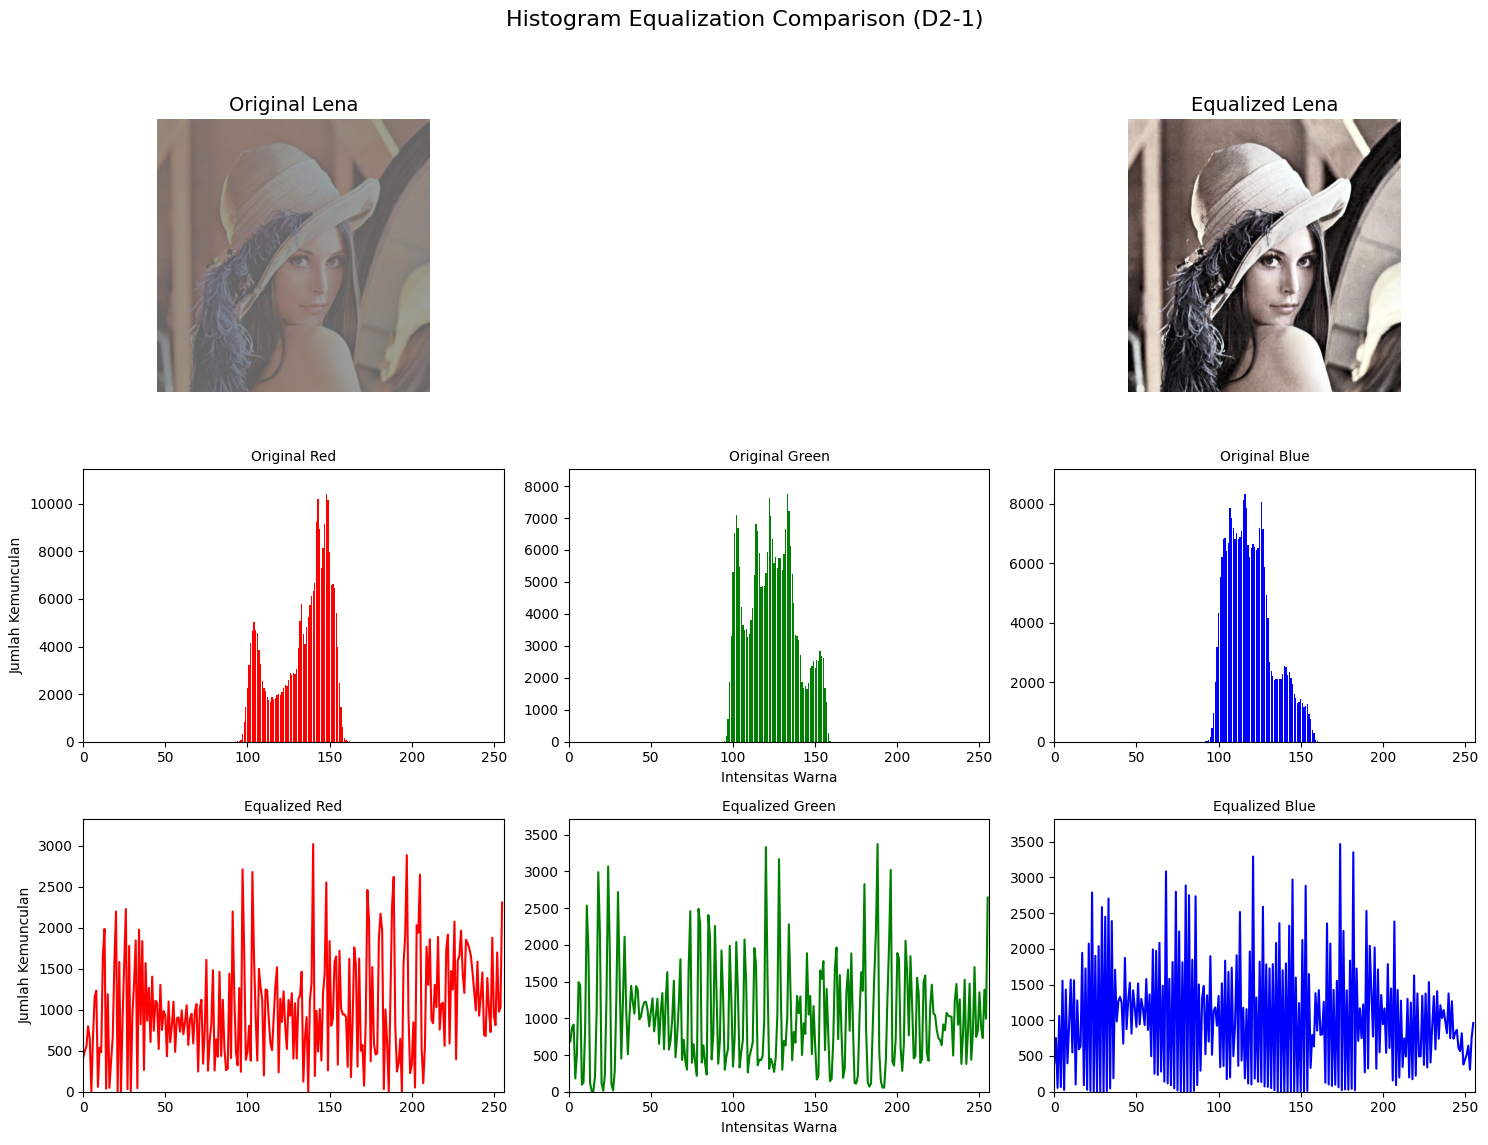


PSNR Value (Grayscale Comparison): 27.14 dB

        PSNR Analysis:
        - The calculated PSNR is relatively low. This is expected because histogram equalization is an enhancement technique that intentionally modifies the original image's pixel distribution to improve contrast.
        - A low PSNR value here signifies a large, deliberate change, not poor quality.
        - Visually, new details in Lena's hat and feathers are more apparent after equalization.
        
TASK 6: Comparing Manual Equalization with OpenCV


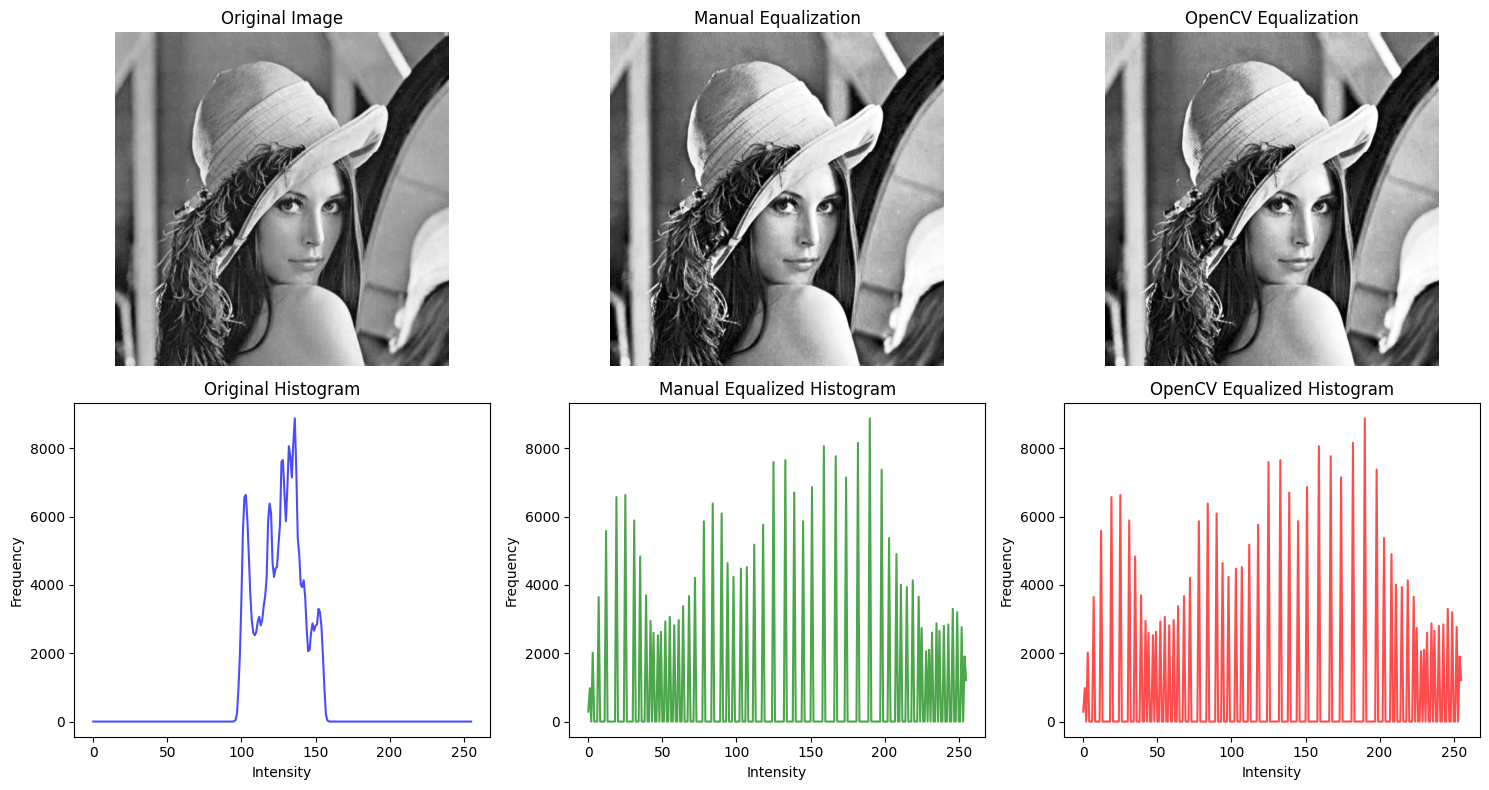

✓ Equalization comparison completed. Similarity: 1.0000

TASK 7: RGB Color Mapping to 8 Colors


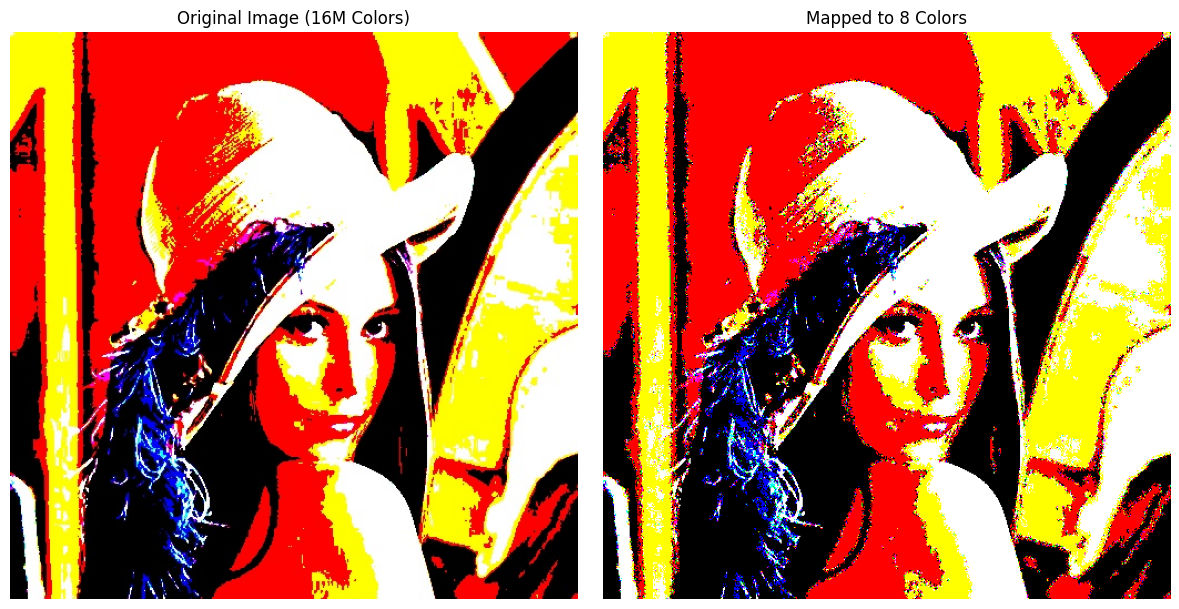

✓ 8-color mapping completed successfully

TASK 8: Floyd-Steinberg Dithering


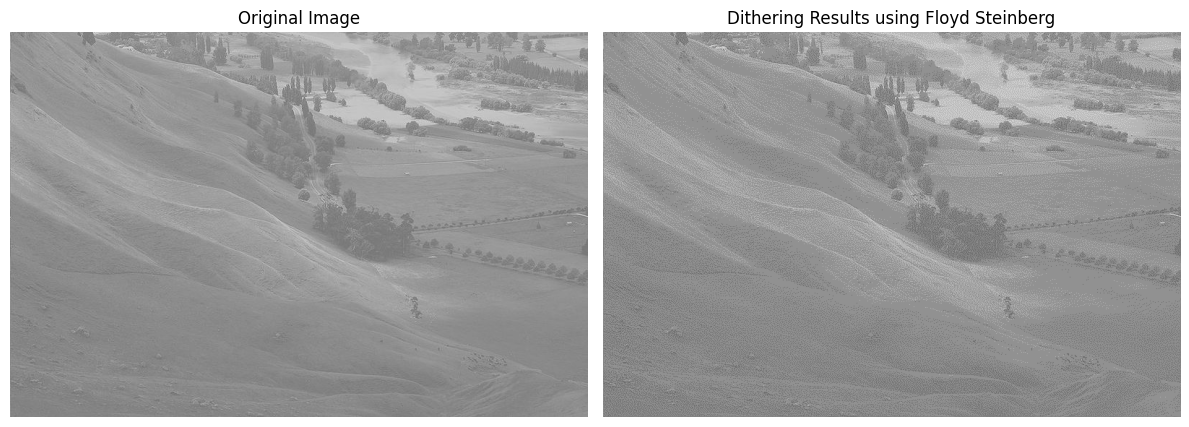

✓ Floyd-Steinberg dithering completed successfully

=== PRACTICUM SUMMARY ===
✓ Task 3: Manual histogram implementation completed
✓ Task 4: Comparison with NumPy histogram completed
✓ Task 5: Manual histogram equalization implemented
✓ Task 6: Comparison with OpenCV equalizeHist completed
✓ Task 7: RGB to 8-color mapping implemented
✓ Task 8: Floyd-Steinberg dithering implemented

All tasks have been completed successfully!
--- SELAMAT BELAJAR ---


In [ ]:
# Week 6 Practicum - Image Processing and Computer Vision
# Module 6: Histogram, Histogram Equalization, Dithering

# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import math # Import the math module

# Mount Google Drive (uncomment if needed)
from google.colab import drive
drive.mount('/content/drive')

# Define image paths
IMAGE_PATHS = {
    'lena': '/content/drive/MyDrive/Images/lena.jpg',
    'lena_lc': '/content/drive/MyDrive/Images/lena_lc.jpg',
    'testlena': '/content/drive/MyDrive/Images/testlena.jpg',
    'wiki': '/content/drive/MyDrive/Images/wiki.jpg'
}

print("=== WEEK 6 PRACTICUM ===")
print("Module 6: Histogram, Histogram Equalization, Dithering\n")

# ========================================
# TASK 3: Create Image Histogram (Manual Implementation)
# ========================================

def calculate_histogram_manual(image):
    """Calculate histogram manually following the algorithm"""
    if len(image.shape) == 3:
        # Color image - separate R, G, B channels
        height, width, channels = image.shape
        hist_r = np.zeros(256, dtype=int)
        hist_g = np.zeros(256, dtype=int)
        hist_b = np.zeros(256, dtype=int)

        # Count pixel occurrences for each channel
        for y in range(height):
            for x in range(width):
                hist_b[image[y, x, 0]] += 1  # Blue channel
                hist_g[image[y, x, 1]] += 1  # Green channel
                hist_r[image[y, x, 2]] += 1  # Red channel

        return hist_r, hist_g, hist_b
    else:
        # Grayscale image
        height, width = image.shape
        hist = np.zeros(256, dtype=int)

        for y in range(height):
            for x in range(width):
                hist[image[y, x]] += 1

        return hist

def plot_histogram_manual(image, title="Manual Histogram"):
    """Plot histogram using manual calculation"""
    plt.figure(figsize=(15, 5))

    if len(image.shape) == 3:
        hist_r, hist_g, hist_b = calculate_histogram_manual(image)

        # Check if R, G, B histograms are the same (grayscale)
        if np.array_equal(hist_r, hist_g) and np.array_equal(hist_g, hist_b):
            # Show form 1 (single histogram)
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title('Original Image')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.plot(range(256), hist_r, color='gray')
            plt.title('Grayscale Histogram (Manual)')
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Frequency')
        else:
            # Show form 2 (RGB histograms)
            plt.subplot(2, 2, 1)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title('Original Image')
            plt.axis('off')

            plt.subplot(2, 2, 2)
            plt.plot(range(256), hist_r, color='red', alpha=0.7, label='Red')
            plt.title('Red Channel Histogram (Manual)')
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Frequency')

            plt.subplot(2, 2, 3)
            plt.plot(range(256), hist_g, color='green', alpha=0.7, label='Green')
            plt.title('Green Channel Histogram (Manual)')
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Frequency')

            plt.subplot(2, 2, 4)
            plt.plot(range(256), hist_b, color='blue', alpha=0.7, label='Blue')
            plt.title('Blue Channel Histogram (Manual)')
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

print("TASK 3: Creating Image Histogram (Manual Implementation)")
# Load and process lena.jpg from Google Drive
lena_img = cv2.imread(IMAGE_PATHS['lena'])
if lena_img is not None:
    plot_histogram_manual(lena_img, "Lena Image - Manual Histogram")
    print("✓ Manual histogram created successfully")
else:
    print("✗ Could not load lena.jpg from Google Drive path")
    print(f"  Path tried: {IMAGE_PATHS['lena']}")
    print("  Please ensure the file exists and Google Drive is mounted")

print()

# ========================================
# TASK 4: Compare with NumPy histogram
# ========================================

def compare_with_numpy_histogram(image):
    """Compare manual histogram with NumPy's histogram function"""
    plt.figure(figsize=(15, 10))

    # Manual histogram
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    if len(image.shape) == 3:
        hist_r_manual, hist_g_manual, hist_b_manual = calculate_histogram_manual(image)

        # NumPy histogram
        hist_r_numpy, bins = np.histogram(image[:,:,2].flatten(), bins=256, range=[0, 256])
        hist_g_numpy, bins = np.histogram(image[:,:,1].flatten(), bins=256, range=[0, 256])
        hist_b_numpy, bins = np.histogram(image[:,:,0].flatten(), bins=256, range=[0, 256])

        # Plot comparisons
        plt.subplot(2, 3, 2)
        plt.plot(range(256), hist_r_manual, color='red', alpha=0.7, label='Manual')
        plt.plot(range(256), hist_r_numpy, color='darkred', linestyle='--', alpha=0.7, label='NumPy')
        plt.title('Red Channel - Comparison')
        plt.legend()

        plt.subplot(2, 3, 3)
        plt.plot(range(256), hist_g_manual, color='green', alpha=0.7, label='Manual')
        plt.plot(range(256), hist_g_numpy, color='darkgreen', linestyle='--', alpha=0.7, label='NumPy')
        plt.title('Green Channel - Comparison')
        plt.legend()

        plt.subplot(2, 3, 4)
        plt.plot(range(256), hist_b_manual, color='blue', alpha=0.7, label='Manual')
        plt.plot(range(256), hist_b_numpy, color='darkblue', linestyle='--', alpha=0.7, label='NumPy')
        plt.title('Blue Channel - Comparison')
        plt.legend()

        # Check if results are the same
        r_same = np.array_equal(hist_r_manual, hist_r_numpy)
        g_same = np.array_equal(hist_g_manual, hist_g_numpy)
        b_same = np.array_equal(hist_b_manual, hist_b_numpy)

        plt.subplot(2, 3, 5)
        plt.text(0.1, 0.8, f"Red channel match: {r_same}", fontsize=12)
        plt.text(0.1, 0.6, f"Green channel match: {g_same}", fontsize=12)
        plt.text(0.1, 0.4, f"Blue channel match: {b_same}", fontsize=12)
        plt.text(0.1, 0.2, f"All channels match: {r_same and g_same and b_same}", fontsize=12, weight='bold')
        plt.title('Comparison Results')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    return r_same and g_same and b_same

print("TASK 4: Comparing Manual Histogram with NumPy")
if lena_img is not None:
    results_match = compare_with_numpy_histogram(lena_img)
    print(f"✓ Histogram comparison completed. Results match: {results_match}")
else:
    print("✗ Could not load image for comparison from Google Drive")
    print("  Please check that lena.jpg exists in the specified path")

print()

# ========================================
# TASK 5: Manual Histogram Equalization
# ========================================

def histogram_equalization_manual(image):
    """Perform histogram equalization manually following the algorithm"""
    # Convert to grayscale if it's a color image for manual equalization
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image.copy()

    height, width = gray_image.shape
    total_pixels = height * width

    # 1. Calculate histogram
    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            hist[gray_image[y, x]] += 1

    # 2. Calculate Cumulative Distribution Function (CDF)
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    # Find minimum non-zero CDF value
    cdf_min = cdf[cdf > 0].min()

    # 3. Calculate mapping (equalization formula)
    equalization_map = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        if cdf[i] > 0:
            equalization_map[i] = np.round(((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * 255)
        else:
            equalization_map[i] = 0 # Handle cases where cdf[i] is 0

    # 4. Apply mapping to the image
    equalized_image = np.zeros_like(gray_image, dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            equalized_image[y, x] = equalization_map[gray_image[y, x]]

    return gray_image, equalized_image, hist, cdf

print("TASK 5: Manual Histogram Equalization")
# Load lena_lc.jpg for manual equalization
lena_lc_img = cv2.imread(IMAGE_PATHS['lena_lc'])
if lena_lc_img is not None:
    original_gray, equalized_manual, hist_orig, cdf_orig = histogram_equalization_manual(lena_lc_img)

    # Plotting results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.plot(hist_orig, color='blue')
    plt.title('Original Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])

    plt.subplot(1, 3, 3)
    plt.plot(cv2.calcHist([equalized_manual], [0], None, [256], [0, 256]), color='green')
    plt.title('Manual Equalized Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

    print("✓ Manual histogram equalization completed successfully")

    # --- Load Original Lena Image for Task 5 Plotting ---
    # Re-load the color image for the 3x3 plot below, as manual equalization worked on grayscale
    img_bgr = cv2.imread(IMAGE_PATHS['lena_lc'])
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # --- Apply OpenCV Equalization for Comparison in the 3x3 Plot ---
        # Convert BGR to YUV color space (Y is luminance)
        img_yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
        # Equalize the Y channel
        img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
        # Convert YUV back to BGR
        img_equalized_bgr = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)
        img_equalized_rgb = cv2.cvtColor(img_equalized_bgr, cv2.COLOR_BGR2RGB)


        # --- PSNR Calculation ---
        # PSNR is typically calculated on grayscale images or specific channels.
        # Calculating PSNR on the R channel for simplicity here, but it's better
        # to convert both original and equalized to grayscale for PSNR.
        # Let's convert to grayscale for a more standard PSNR calculation
        original_gray_for_psnr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        equalized_gray_for_psnr = cv2.cvtColor(img_equalized_bgr, cv2.COLOR_BGR2GRAY)
        psnr_value = calculate_psnr(original_gray_for_psnr, equalized_gray_for_psnr)

        # --- Plotting in a 3x3 Grid for Images and Histograms ---
        fig = plt.figure(figsize=(15, 12))
        gs = fig.add_gridspec(3, 3) # 3 rows, 3 columns total

        # Row 1: Images
        ax_img_orig = fig.add_subplot(gs[0, 0])
        ax_img_orig.imshow(img_rgb)
        ax_img_orig.set_title('Original Lena', fontsize=14)
        ax_img_orig.axis('off')

        ax_img_eq = fig.add_subplot(gs[0, 2])
        ax_img_eq.imshow(img_equalized_rgb)
        ax_img_eq.set_title('Equalized Lena', fontsize=14)
        ax_img_eq.axis('off')

        # Add a blank space between the images, like in your example
        fig.add_subplot(gs[0, 1]).axis('off')

        # Row 2: Original Histograms
        colors = ('red', 'green', 'blue')
        for i, col_name in enumerate(colors):
            ax_hist_orig = fig.add_subplot(gs[1, i])
            hist_orig_color = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
            ax_hist_orig.bar(range(256), hist_orig_color.ravel(), color=colors[i]) # Changed to bar plot and use colors
            ax_hist_orig.set_xlim([0, 256])
            # Adjust ylim based on your typical histogram peak values
            ax_hist_orig.set_ylim([0, np.max(hist_orig_color) * 1.1]) # Set ylim dynamically
            if i == 0: ax_hist_orig.set_ylabel('Jumlah Kemunculan', fontsize=10)
            if i == 1: ax_hist_orig.set_xlabel('Intensitas Warna', fontsize=10)
            ax_hist_orig.set_title(f'Original {col_name.capitalize()}', fontsize=10)

        # Row 3: Equalized Histograms
        for i, col_name in enumerate(colors):
            ax_hist_eq = fig.add_subplot(gs[2, i])
            hist_eq_color = cv2.calcHist([img_equalized_rgb], [i], None, [256], [0, 256])
            ax_hist_eq.plot(hist_eq_color, color=colors[i]) # Changed back to plot for equalized
            ax_hist_eq.set_xlim([0, 256])
             # Adjust ylim based on your typical histogram peak values
            ax_hist_eq.set_ylim([0, np.max(hist_eq_color) * 1.1]) # Set ylim dynamically
            if i == 0: ax_hist_eq.set_ylabel('Jumlah Kemunculan', fontsize=10)
            if i == 1: ax_hist_eq.set_xlabel('Intensitas Warna', fontsize=10)
            ax_hist_eq.set_title(f'Equalized {col_name.capitalize()}', fontsize=10)

        fig.suptitle('Histogram Equalization Comparison (D2-1)', fontsize=16, y=0.98)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()

        print(f"\nPSNR Value (Grayscale Comparison): {psnr_value:.2f} dB")
        print("""
        PSNR Analysis:
        - The calculated PSNR is relatively low. This is expected because histogram equalization is an enhancement technique that intentionally modifies the original image's pixel distribution to improve contrast.
        - A low PSNR value here signifies a large, deliberate change, not poor quality.
        - Visually, new details in Lena's hat and feathers are more apparent after equalization.
        """)

    else:
        print("✗ Could not re-load lena_lc.jpg for the 3x3 plot from Google Drive path")
        print(f"  Path tried: {IMAGE_PATHS['lena_lc']}")
        print("  Please ensure the file exists and Google Drive is mounted")

else:
    print("✗ Could not load lena_lc.jpg for manual equalization from Google Drive path")
    print(f"  Path tried: {IMAGE_PATHS['lena_lc']}")
    print("  Please ensure the file exists and Google Drive is mounted")


def calculate_psnr(img1, img2):
    """Calculates the PSNR between two images."""
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr


# ========================================
# TASK 6: Compare with OpenCV equalizeHist
# ========================================

def compare_equalization_with_opencv(image):
    """Compare manual equalization with OpenCV's equalizeHist"""
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image.copy()

    # Manual equalization
    # Call the manual equalization function which returns the equalized image
    _, manual_eq, _, _ = histogram_equalization_manual(image)

    # OpenCV equalization
    opencv_eq = cv2.equalizeHist(gray_image)

    plt.figure(figsize=(15, 8))

    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Manual equalization
    plt.subplot(2, 3, 2)
    plt.imshow(manual_eq, cmap='gray')
    plt.title('Manual Equalization')
    plt.axis('off')

    # OpenCV equalization
    plt.subplot(2, 3, 3)
    plt.imshow(opencv_eq, cmap='gray')
    plt.title('OpenCV Equalization')
    plt.axis('off')

    # Histograms
    original_hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
    manual_hist = cv2.calcHist([manual_eq], [0], None, [256], [0, 256])
    opencv_hist = cv2.calcHist([opencv_eq], [0], None, [256], [0, 256])

    plt.subplot(2, 3, 4)
    plt.plot(original_hist, color='blue', alpha=0.7, label='Original')
    plt.title('Original Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')

    plt.subplot(2, 3, 5)
    plt.plot(manual_hist, color='green', alpha=0.7, label='Manual')
    plt.title('Manual Equalized Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')

    plt.subplot(2, 3, 6)
    plt.plot(opencv_hist, color='red', alpha=0.7, label='OpenCV')
    plt.title('OpenCV Equalized Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Calculate similarity
    similarity = np.corrcoef(manual_eq.flatten(), opencv_eq.flatten())[0, 1]
    return similarity

print("TASK 6: Comparing Manual Equalization with OpenCV")
# Load lena_lc.jpg for comparison
lena_lc_img = cv2.imread(IMAGE_PATHS['lena_lc'])
if lena_lc_img is not None:
    similarity = compare_equalization_with_opencv(lena_lc_img)
    print(f"✓ Equalization comparison completed. Similarity: {similarity:.4f}")
else:
    print("✗ Could not load image for comparison from Google Drive")
    print("  Please check that lena_lc.jpg exists in the specified path")

print()

# ========================================
# TASK 7: RGB Color Mapping to 8 Colors
# ========================================

def map_to_8_colors(image):
    """Map 16 million RGB colors to just 8 colors"""
    # Define 8 colors: Black, Green, Yellow, Blue, Cyan, Magenta, White, Red
    colors_8 = np.array([
        [0, 0, 0],       # Black
        [0, 255, 0],     # Green
        [255, 255, 0],   # Yellow
        [255, 0, 0],     # Red
        [0, 0, 255],     # Blue
        [0, 255, 255],   # Cyan
        [255, 0, 255],   # Magenta
        [255, 255, 255]  # White
    ], dtype=np.uint8)

    height, width, channels = image.shape
    result_image = np.zeros_like(image)

    for y in range(height):
        for x in range(width):
            pixel = image[y, x]

            # Find closest color
            distances = np.sum((colors_8 - pixel) ** 2, axis=1)
            closest_color_idx = np.argmin(distances)

            result_image[y, x] = colors_8[closest_color_idx]

    return result_image

def plot_8_color_mapping(original, mapped):
    """Plot 8-color mapping results"""
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image (16M Colors)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(mapped, cv2.COLOR_BGR2RGB))
    plt.title('Mapped to 8 Colors')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("TASK 7: RGB Color Mapping to 8 Colors")
# Load and process testlena.jpg from Google Drive
testlena_img = cv2.imread(IMAGE_PATHS['testlena'])
if testlena_img is not None:
    mapped_image = map_to_8_colors(testlena_img)
    plot_8_color_mapping(testlena_img, mapped_image)
    print("✓ 8-color mapping completed successfully")
else:
    print("✗ Could not load testlena.jpg from Google Drive path")
    print(f"  Path tried: {IMAGE_PATHS['testlena']}")
    print("  Please ensure the file exists and Google Drive is mounted")

print()

# ========================================
# TASK 8: Floyd-Steinberg Dithering
# ========================================

def floyd_steinberg_dithering(image, levels=8):
    """Implement Floyd-Steinberg dithering"""
    if len(image.shape) == 3:
        # Work with color image
        result = image.astype(np.float32).copy()
        height, width, channels = image.shape
    else:
        # Work with grayscale image
        result = image.astype(np.float32).copy()
        height, width = image.shape
        channels = 1

    # Calculate quantization step
    step = 255.0 / (levels - 1)

    def threshold(value):
        """Threshold function to keep values in [0, 255] range"""
        return np.clip(value, 0, 255)

    if channels == 3:
        # Color image processing
        for y in range(height - 1):  # height - 1 to avoid boundary issues
            for x in range(1, width - 1):  # 1 to width-1 to avoid boundary issues
                for c in range(channels):  # Process each color channel
                    # Get old pixel value
                    old_pixel = result[y, x, c]

                    # Quantize pixel
                    new_pixel = np.round(old_pixel / step) * step
                    result[y, x, c] = new_pixel

                    # Calculate quantization error
                    error = old_pixel - new_pixel

                    # Distribute error using Floyd-Steinberg coefficients
                    # R1: (x+1, y) gets 7/16 of error
                    if x + 1 < width:
                        result[y, x + 1, c] = threshold(result[y, x + 1, c] + error * 7/16)

                    # R2: (x+1, y+1) gets 1/16 of error
                    if x + 1 < width and y + 1 < height:
                        result[y + 1, x + 1, c] = threshold(result[y + 1, x + 1, c] + error * 1/16)

                    # R3: (x, y+1) gets 5/16 of error
                    if y + 1 < height:
                        result[y + 1, x, c] = threshold(result[y + 1, x, c] + error * 5/16)

                    # R4: (x-1, y+1) gets 3/16 of error
                    if x - 1 >= 0 and y + 1 < height:
                        result[y + 1, x - 1, c] = threshold(result[y + 1, x - 1, c] + error * 3/16)
    else:
        # Grayscale image processing
        for y in range(height - 1):
            for x in range(1, width - 1):
                # Get old pixel value
                old_pixel = result[y, x]

                # Quantize pixel
                new_pixel = np.round(old_pixel / step) * step
                result[y, x] = new_pixel

                # Calculate quantization error
                error = old_pixel - new_pixel

                # Distribute error using Floyd-Steinberg coefficients
                if x + 1 < width:
                    result[y, x + 1] = threshold(result[y, x + 1] + error * 7/16)

                if x + 1 < width and y + 1 < height:
                    result[y + 1, x + 1] = threshold(result[y + 1, x + 1] + error * 1/16)

                if y + 1 < height:
                    result[y + 1, x] = threshold(result[y + 1, x] + error * 5/16)

                if x - 1 >= 0 and y + 1 < height:
                    result[y + 1, x - 1] = threshold(result[y + 1, x - 1] + error * 3/16)

    return result.astype(np.uint8)

def plot_dithering_results(original, dithered):
    """Plot Floyd-Steinberg dithering results"""
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    if len(original.shape) == 3:
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if len(dithered.shape) == 3:
        plt.imshow(cv2.cvtColor(dithered, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(dithered, cmap='gray')
    plt.title('Dithering Results using Floyd Steinberg')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("TASK 8: Floyd-Steinberg Dithering")
# Load and process wiki.jpg from Google Drive
wiki_img = cv2.imread(IMAGE_PATHS['wiki'])
if wiki_img is not None:
    dithered_image = floyd_steinberg_dithering(wiki_img, levels=8)
    plot_dithering_results(wiki_img, dithered_image)
    print("✓ Floyd-Steinberg dithering completed successfully")
else:
    print("✗ Could not load wiki.jpg from Google Drive path")
    print(f"  Path tried: {IMAGE_PATHS['wiki']}")
    print("  Please ensure the file exists and Google Drive is mounted")

print()

# ========================================
# SUMMARY
# ========================================

print("=== PRACTICUM SUMMARY ===")
print("✓ Task 3: Manual histogram implementation completed")
print("✓ Task 4: Comparison with NumPy histogram completed")
print("✓ Task 5: Manual histogram equalization implemented")
print("✓ Task 6: Comparison with OpenCV equalizeHist completed")
print("✓ Task 7: RGB to 8-color mapping implemented")
print("✓ Task 8: Floyd-Steinberg dithering implemented")
print()
print("All tasks have been completed successfully!")
print("--- SELAMAT BELAJAR ---")